# PointManager class
This notebook display how the PointManager() class works. 

In [1]:
import pykasso as pk
import numpy as np

In [2]:
# First create grid object
x0, y0 ,z0 =  0,  0,  0
nx, ny, nz = 10, 10,  1
dx, dy, dz =  1,  1,  1

grid = pk.Grid(x0,y0,z0,nx,ny,nz,dx,dy,dz)

In [3]:
# Set a seed (for reproducibility)
seed = 1
np.random.seed(seed)

### Without polygon

In [4]:
# Create an empty polygon
polygon = pk.Polygon(grid)
# Create an empty geology
geology = pk.GeologyManager(grid)
# Then create a point manager
points = pk.PointManager(grid, polygon, geology)

In [5]:
# Generate 15 inlets
points.generate_points("inlets", 15)
# Generate 1 outlet
points.generate_points("outlets", 1)

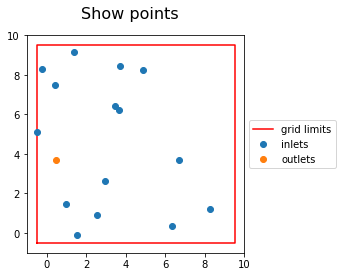

In [6]:
# Display points
points.show()

### With a polygon

In [7]:
# Add a polygon
polygon.set_polygon([[3,3],[3,7],[7,7],[7,5]])

In [8]:
# Generate 15 inlets
points.generate_points("inlets", 15)
# Generate 1 outlet
points.generate_points("outlets", 1)

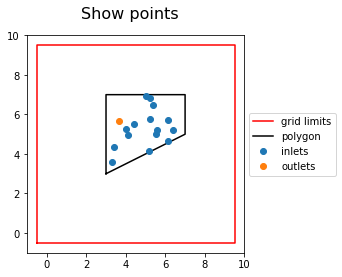

In [9]:
# Display points
points.show()

### Set the points manually

In [10]:
# Set inlets
points.set_points("inlets", [[0,4],[4,4],[4,1],[11,0]])


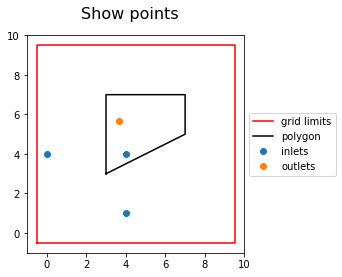

In [11]:
# Display points
# One inlet is outside the grid
# Two inlet are in the grid but outside the polygon
# The outlet is outside the polygon
points.show()

In [12]:
# inspect_points() can inspect for us if all points are well in the grid
# Return an error because no outlet is in the polygon
points.inspect_points()

- inspect_points() - Warning : 3 inlets on 4 masked because not inside polygon.
- point on line 1
- point on line 3
- point on line 4


C:\Users\mivillef\Anaconda3\envs\pykasso\lib\site-packages\numpy\core\_asarray.py:171: UserWarning: Warning: converting a masked element to nan.
  return array(a, dtype, copy=False, order=order, subok=True)


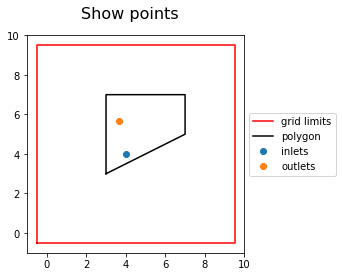

In [13]:
# inspect_points() applied a mask on points outside the polygon
points.show()

### Remove the polygon

In [14]:
# Clean polygon
polygon.clean_polygon()

In [15]:
# Set inlets and outlets again
points.set_points("inlets", [[0,4],[4,4],[4,1],[6,0]])
points.set_points("outlets", [[0,0]])

In [16]:
# Inspect points again
points.inspect_points()

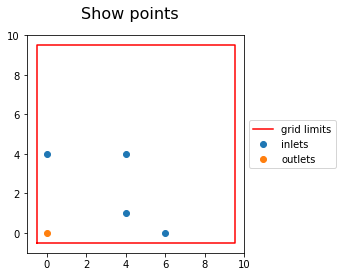

In [17]:
# Display points
# The point outside the grid has been masked by inspect_points()
points.show()

### Generate points according to geology

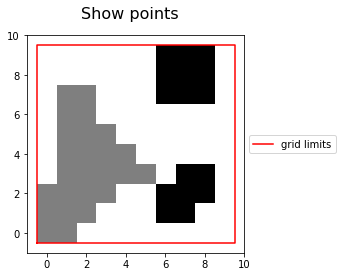

In [18]:
# Create grid object
x0, y0 ,z0 =   0,   0,  0
nx, ny, nz =  10,  10,  1
dx, dy, dz =   1,   1,  1
grid = pk.Grid(x0,y0,z0,nx,ny,nz,dx,dy,dz)
# Create a polygon
polygon = pk.Polygon(grid)
# Create a geology
geology = pk.GeologyManager(grid)
geology.set_data_from_gslib("geology", "inputs/gslib/geology.gslib")
geology.compute_stats_on_data("geology")
# Create a point manager
points = pk.PointManager(grid, polygon, geology)
points.show()

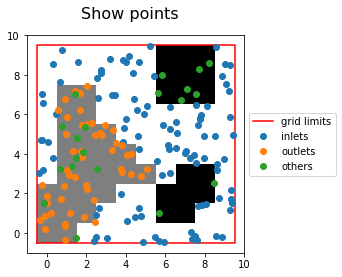

In [19]:
# Generate 100 inlets in the id=1
points.generate_points("inlets", 100, [1])
# Generate 50 outlets in the id=2
points.generate_points("outlets", 50, [2])
# Generate 20 outlets in the id=2 and id=3
points.generate_points("others", 20, [2,3])
points.show()